# General notebook preparation: Libaries and Datasets

At the beginning, the basic libaries that we work with need to be imported. That includes pandas for data read out, matplot libary for basic plotting, numpy for numeric operations, seaborn for advanced plotting and scipy stats for statistical calculations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from pathlib import Path
from statsmodels.stats.multitest import multipletests

Here, our cleaned-up and filtered ATAC-seq dataset is imported.

In [2]:
ATAC_path_pfiltered = Path('data') / 'ATAC_pfiltered.csv'
ATAC_pfiltered = pd.read_csv(ATAC_path_pfiltered)
ATAC_pfiltered.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02


This dataset is a subunit of ATAC_pfiltered, but only with the Tgd-cells cells.

In [3]:
ATAC_path_Tgd = Path('data') / 'ATAC_seq_gd_anot.csv'
ATAC_Tgd = pd.read_csv(ATAC_path_Tgd)
ATAC_Tgd.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,0.11,0.40,...,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.11,0.46,...,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.11,0.77,...,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,1.58,0.77,...,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.11,0.40,...,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73


Finally, the cleaned-up RNA-seq dataset is read out. For further analysis, a RNA-seq dataset including only the Tgd-cells is also created.

In [4]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq = RNA_seq.set_index("Unnamed: 0")  # Gennamen als Index setzen

Tgd_cells = [
    "MPP4.135+.BM",
    "preT.DN1.Th",
    "preT.DN2a.Th",
    "preT.DN2b.Th",
    "preT.DN3.Th",
    "T.DN4.Th",
    "Tgd.g1.1+d1.24a+.Th",
    "Tgd.g2+d1.24a+.Th",
    "Tgd.g2+d17.24a+.Th",
    "Tgd.Sp",
    "Tgd.g1.1+d1.LN",
    "Tgd.g2+d1.LN",
    "Tgd.g2+d17.LN"
]

RNA_Tgd = RNA_seq[Tgd_cells].copy()
RNA_Tgd.head()


,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
Unnamed: 0,,,,,,,,,,,,,
0610005C13Rik,1.021812,1.022363,1.389747,1.024819,1.024482,1.026430,1.023995,1.167561,1.024819,1.023995,1.025543,1.024819,1.023995
0610007P14Rik,204.298358,162.641117,206.945221,209.187788,198.421365,215.056475,150.742022,174.031477,115.930664,136.200789,108.850425,102.701399,137.925015
0610009B22Rik,76.418169,68.070719,82.468806,89.769337,57.661619,76.399214,47.775227,44.980534,53.461136,42.439750,28.755395,21.517647,29.122837
0610009L18Rik,16.947354,15.450717,13.573968,14.427620,8.249482,1.683173,8.554990,8.781962,29.156630,8.937625,10.815319,10.202163,9.033355
0610009O20Rik,186.261464,160.246297,125.475307,155.928005,120.692893,118.433597,94.062684,113.600798,102.445617,79.315094,84.643541,106.186930,86.383381


In [5]:
meta_cols = ["TSS", "genes.within.100Kb", "_-log10_bestPvalue", "Included.in.systematic.analysis",
             "ImmGenATAC1219.peakID", "chrom", "Summit", "mm10.60way.phastCons_scores"]
signal_cols_all = [col for col in ATAC_pfiltered.columns 
                   if col not in meta_cols 
                   and col in RNA_seq.columns] #alle Zelltypen Spaltennamen in ATAC, 
#ohne meta_cols und nur, wenn in ATAC, aber als liste und
signal_cols_all

signal_cols_tgd = Tgd_cells 

Last but not least, the gene annotations data set is read out, which included data regarding the genes strand, transcription start and -end and more gene-related information.

In [6]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]

ATAC_path_genanno = Path("data") / "Gene annotations.txt"

Gene_annotations = pd.read_csv(
    ATAC_path_genanno,
    sep="\t",
    names=cols
)

Gene_annotations.head()

,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
0,Wdsub1,NM_001159636,chr2,-,59855193,59882606,59855270,59878527,11,"59855193,59858609,59861560,59862619,59862816,5...","59855275,59858750,59861737,59862726,59862857,5..."
1,Rbm18,NM_001159635,chr2,-,36116078,36136704,36117814,36134247,6,"36116078,36120812,36122851,36127214,36134134,3...","36117974,36120898,36122938,36127251,36134263,3..."
2,Prrc2b,NM_001159634,chr2,+,32151147,32234537,32182511,32230742,32,"32151147,32182457,32183122,32185344,32187480,3...","32151291,32182626,32183300,32185447,32187553,3..."
3,Ildr2,NM_001164528,chr1,+,166254138,166316832,166254375,166310795,10,"166254138,166269304,166270498,166291415,166294...","166254466,166269637,166270618,166291472,166294..."
4,Perm1,NM_172417,chr4,+,156215926,156221307,156217000,156220222,4,"156215926,156216716,156219740,156220109,","156215975,156219185,156219866,156221307,"


# CRE–Gene Association via Correlation

In order to link ATAC-accessibility and RNA-expression to each other, one needs to create signal peak/gene-pairs among ATAC peaks that correspond to a gene within 100kb. After that, the correlation between signal peak (ATAC) and gene expression (RNA) is calculated over either only TGD cells or all cell types. <br> By doing that, it can be investigated whether chromatin accessibility directly influences RNA-expression and if so by what patterns.

## Linking ATAC-seq peaks to genes via Correlation across Tgd cells

First things first, correlaion analysis is performed only across Tgd-cells (13). <br> For this purpose, the stats.correlation function is used here, because it calculates the p-value straight away, which is needed for correction downstream. With the standard pandas series corr() function, the r-value  is the only result one gets and the p-value would need to be calculated manually.

signal_cols_tgd = Tgd_cells 

results_corr_tgd = []

for peak_id, row in ATAC_Tgd[ATAC_Tgd["genes.within.100Kb"].notna()].iterrows():
    peak_signal = row[signal_cols_tgd].values.astype(float)
    gene = row["genes.within.100Kb"]

    for gene_name in str(gene).split(","):
        gene_name = gene_name.strip()

        if gene_name in RNA_Tgd.index:
            gene_expr = RNA_Tgd.loc[gene_name, signal_cols_tgd].values.astype(float)
            r, p = stats.pearsonr(peak_signal, gene_expr)

            results_corr_tgd.append({
                "peak_id": row["ImmGenATAC1219.peakID"],
                "gene":    gene_name,
                "r":       r,
                "p_value": p
            })

results_corr_tgd = pd.DataFrame(results_corr_tgd)
results_corr_tgd.to_csv('data/results_corr_tgd.csv', index=False) 

Here, the Pearson correlation is used, as the RNA and ATAC-Seq datasets had both already been log-transformed, quantile-normalised and then linearised again.In the Yoshida paper, they also use Pearson. Spearman has lower statistical power for data that is approximately normally distributed, as everything is converted into ranks and the differences in values are lost.

Because of extensive loading times, this code cell was turned into a markdown cell to avoid hindering the notebook from being run. The results of this code were safed as a new dataset that can be accessed as following:

In [7]:
results_corr_tgd = pd.read_csv('data/results_corr_tgd.csv')
results_corr_all= pd.read_csv('data/results_corr_all.csv')

In [8]:
print(f"\nAnzahl Korrelationen von TGD-Zellen: {len(results_corr_tgd)}")


Anzahl Korrelationen von TGD-Zellen: 933713


There are in total 933713 peak-gene pairs that have been formed for correlation purposes.

In [9]:
results_corr_tgd.head()

,peak_id,gene,r,p_value
0,ImmGenATAC1219.peak_41,Rp1,-0.009633,0.975083
1,ImmGenATAC1219.peak_43,Rp1,0.060016,0.845581
2,ImmGenATAC1219.peak_46,Rp1,-0.319756,0.286869
3,ImmGenATAC1219.peak_48,Rp1,0.096712,0.753292
4,ImmGenATAC1219.peak_48,Sox17,0.121571,0.692373


In [10]:
results_corr_tgd[results_corr_tgd["r"] > 0.7].sort_values("r", ascending=False)

,peak_id,gene,r,p_value
1979,ImmGenATAC1219.peak_2086,Il17f,0.998686,1.509077e-15
483554,ImmGenATAC1219.peak_274985,Osbpl6,0.998488,3.255187e-15
1959,ImmGenATAC1219.peak_2075,Il17f,0.997891,2.031938e-14
1988,ImmGenATAC1219.peak_2090,Il17f,0.997714,3.162186e-14
338451,ImmGenATAC1219.peak_197929,Abi3bp,0.997449,5.776129e-14
...,...,...,...,...
732006,ImmGenATAC1219.peak_415764,Klra3,0.700007,7.721414e-03
84298,ImmGenATAC1219.peak_54750,Mrpl54,0.700006,7.721590e-03
879679,ImmGenATAC1219.peak_481899,C2cd2l,0.700005,7.721652e-03
483160,ImmGenATAC1219.peak_274706,Nfe2l2,0.700001,7.722104e-03


In [11]:
results_corr_tgd[results_corr_tgd["r"] < -0.7].sort_values("r")

,peak_id,gene,r,p_value
384631,ImmGenATAC1219.peak_216182,1700001C19Rik,-0.964467,1.061594e-07
98985,ImmGenATAC1219.peak_65109,B4galnt1,-0.959915,2.041892e-07
147483,ImmGenATAC1219.peak_83984,Fndc8,-0.944267,1.213607e-06
545115,ImmGenATAC1219.peak_311571,Clk2,-0.944156,1.226766e-06
831664,ImmGenATAC1219.peak_460272,D130040H23Rik,-0.943434,1.314735e-06
...,...,...,...,...
76889,ImmGenATAC1219.peak_53950,E130317F20Rik,-0.700046,7.716545e-03
150674,ImmGenATAC1219.peak_85076,Dhx40,-0.700031,7.718468e-03
533041,ImmGenATAC1219.peak_302989,Cetn4,-0.700006,7.721527e-03
760851,ImmGenATAC1219.peak_424697,Tbcb,-0.700006,7.721551e-03


An overview of the highest vs lowest (negative) pair's correlation values can be seen, the highest being close to 1 and the lowest being almost -1 (as expected).

### Bonferroni correction

As we are testing ~933,000 (peak, gene) pairs, at α = 0.05, ~46,000 pairs would appear significant purely by chance (multiple testing problem). Correction is therefore needed to filter out non-significant associations. The first, most known correction method is Bonferroni correction.

In [12]:
results_corr_tgd = results_corr_tgd.dropna(subset=['p_value']) #man muss einen NaN Korrelationswert rausnehmen, weil das FDR verwirrt...

In [13]:
_, p_bonf, _, _ = multipletests(results_corr_tgd['p_value'], method='bonferroni')
results_corr_tgd['p_bonf'] = p_bonf
#komische Schreibweise, aber multiple sets gibt vier werte zurück und uns interessieren nur die korrgierten p-Werte

# Filtern: nur signifikante Assoziationen behalten
corr_bonf_tgd = results_corr_tgd[results_corr_tgd['p_bonf'] < 0.05]
print(f"Signifikante Assoziationen: {len(corr_bonf_tgd)}")
print(f"Von insgesamt: {len(results_corr_tgd)}")

Signifikante Assoziationen: 303
Von insgesamt: 933712


In [14]:
corr_bonf_tgd.head() #303 übrig-gebliebende signifikante Werte

,peak_id,gene,r,p_value,p_bonf
1959,ImmGenATAC1219.peak_2075,Il17f,0.997891,2.031938e-14,1.897245e-08
1979,ImmGenATAC1219.peak_2086,Il17f,0.998686,1.509077e-15,1.409043e-09
1988,ImmGenATAC1219.peak_2090,Il17f,0.997714,3.162186e-14,2.952571e-08
1997,ImmGenATAC1219.peak_2095,Il17f,0.980563,3.966074e-09,3.703171e-03
2543,ImmGenATAC1219.peak_2573,Ogfrl1,0.977710,8.377823e-09,7.822474e-03


Consequently, there are only 300 significant association pairs left. This is too little of a number to carry on with for further correlation analysis. Since Bonferroni sets too high of a threshhold, FDR correction is chosen as a less radical means of correction for the multiple testing problem and is therefore often applied in genomic studies.

### FDR correction (Benjamin Hochberg)

In [15]:
_ , p_fdr, _, _ = multipletests(results_corr_tgd['p_value'], method='fdr_bh')
results_corr_tgd['p_fdr'] = p_fdr
corr_fdr_tgd = results_corr_tgd[p_fdr < 0.05]

In [16]:
corr_fdr_tgd.head() #10248 übrig-gebliebende signifikante Werte

,peak_id,gene,r,p_value,p_bonf,p_fdr
232,ImmGenATAC1219.peak_229,Npbwr1,0.826966,0.000488,1.0,0.046927
326,ImmGenATAC1219.peak_412,Pcmtd1,0.828240,0.000470,1.0,0.046009
327,ImmGenATAC1219.peak_413,Pcmtd1,0.877619,0.000081,1.0,0.017123
613,ImmGenATAC1219.peak_616,Sgk3,0.867524,0.000122,1.0,0.021803
867,ImmGenATAC1219.peak_716,Arfgef1,0.828007,0.000473,1.0,0.046188


After using FDR correction, a lot more significant correlation pairs are left. Nevertheless, the number is way lower compared to what should be expected when performing correlation analysis across all celltypes, since the sample size is higher and correlation values therfore more stable.



## Linking ATAC-seq peaks to genes via Correlation across all celltypes

Now, the same correlation analysis is carried out, this time across all cell types. The number of correlated pairs are therefore the same, the correlation values change tho due to the bigger sample size of signal signatures for different cell types.

results_corr_all = []

for peak_id, row in ATAC_pfiltered[ATAC_pfiltered["genes.within.100Kb"].notna()].iterrows():
    peak_signal = row[signal_cols_all].values.astype(float)
    gene = row["genes.within.100Kb"]

    for gene_name in str(gene).split(","):
        gene_name = gene_name.strip()

        if gene_name in RNA_seq.index:
            gene_expr = RNA_seq.loc[gene_name, signal_cols_all].values.astype(float)
            r, p = stats.pearsonr(peak_signal, gene_expr)

            results_corr_all.append({
                "peak_id": row["ImmGenATAC1219.peakID"],
                "gene":    gene_name,
                "r":       r,
                "p_value": p
            })

results_corr_all = pd.DataFrame(results_corr_all)
results_corr_all.to_csv('data/results_corr_all.csv', index=False) 

This calculation takes even more time than the one with only Tgd cells, thats why the correlation results were also safed as a new data set.

In [17]:
print(f"\nAnzahl Korrelationen von allen Zellen: {len(results_corr_all)}")


Anzahl Korrelationen von allen Zellen: 933713


In [18]:
results_corr_all.head()

,peak_id,gene,r,p_value
0,ImmGenATAC1219.peak_41,Rp1,-0.078288,4.763487e-01
1,ImmGenATAC1219.peak_43,Rp1,-0.131412,2.305944e-01
2,ImmGenATAC1219.peak_46,Rp1,0.373676,4.272850e-04
3,ImmGenATAC1219.peak_48,Rp1,0.803798,2.052007e-20
4,ImmGenATAC1219.peak_48,Sox17,0.022633,8.370992e-01


In [19]:
results_corr_all[results_corr_all["r"] > 0.7].sort_values("r")

,peak_id,gene,r,p_value
332448,ImmGenATAC1219.peak_193454,Itgb5,0.700003,9.012261e-14
31935,ImmGenATAC1219.peak_22791,Shisa4,0.700008,9.007129e-14
581111,ImmGenATAC1219.peak_332683,5730488B01Rik,0.700018,8.997207e-14
593063,ImmGenATAC1219.peak_343934,Yipf1,0.700022,8.993124e-14
917778,ImmGenATAC1219.peak_501440,Ccr9,0.700024,8.990992e-14
...,...,...,...,...
485282,ImmGenATAC1219.peak_276303,Serping1,0.995585,4.569541e-87
794941,ImmGenATAC1219.peak_441054,Calcb,0.995828,4.380303e-88
41801,ImmGenATAC1219.peak_30580,Ddr2,0.996070,3.683310e-89
196043,ImmGenATAC1219.peak_104763,Clec14a,0.996494,3.267506e-91


In [20]:
len(results_corr_all[results_corr_all["r"] > 0.7].sort_values("r"))

16743

In [21]:
len(results_corr_tgd[results_corr_tgd["r"] > 0.7].sort_values("r"))

30925

In [22]:
results_corr_all[results_corr_all["r"] < -0.7].sort_values("r")

,peak_id,gene,r,p_value
799232,ImmGenATAC1219.peak_444008,Lat,-0.733080,1.504707e-15
929593,ImmGenATAC1219.peak_509214,Btk,-0.722989,5.581734e-15
874697,ImmGenATAC1219.peak_478534,Vps26b,-0.722896,5.648135e-15
702325,ImmGenATAC1219.peak_401472,Eif2ak3,-0.722858,5.675038e-15
132811,ImmGenATAC1219.peak_79952,Trp53,-0.722285,6.102988e-15
682133,ImmGenATAC1219.peak_386810,Rnf216,-0.719037,9.182620e-15
484851,ImmGenATAC1219.peak_276252,Clp1,-0.718876,9.369464e-15
905381,ImmGenATAC1219.peak_496615,Vprbp,-0.707943,3.553768e-14
726600,ImmGenATAC1219.peak_413884,Ltbr,-0.705403,4.802000e-14


### FDR correction (Benjamin Hochberg)

In [23]:
_ , p_fdr, _, _ = multipletests(results_corr_all['p_value'], method='fdr_bh')
results_corr_all['p_fdr'] = p_fdr
corr_fdr_all = results_corr_all[p_fdr < 0.05]

In [24]:
len(corr_fdr_all)

188177

In [25]:
corr_fdr_all.head()

,peak_id,gene,r,p_value,p_fdr
2,ImmGenATAC1219.peak_46,Rp1,0.373676,4.272850e-04,3.650719e-03
3,ImmGenATAC1219.peak_48,Rp1,0.803798,2.052007e-20,2.529354e-18
7,ImmGenATAC1219.peak_52,Rp1,0.725175,4.222263e-15,2.807964e-13
8,ImmGenATAC1219.peak_52,Sox17,0.422994,5.504399e-05,6.168644e-04
9,ImmGenATAC1219.peak_53,Rp1,0.876096,5.013480e-28,1.352543e-25


With more cell types as the basis for correlation pairs, we do indeed have fewer values with a correlation coefficient r above 0.7; however, we have far more with a stable p-value and thus far more that pass the FDR test. This is because, with 13 cell types, there is greater variation (randomly high r-values) which are then not statistically significant. Increasing the number of cell types used as the basis makes the r value more robust and the correlation more meaningful.

# Distance of significant correlated peaks to TSS start-site

Also interesting from an biological standpoint ist to analyze where the significant correlated OCRs are located in relation to the TSS. 

## Distance calculation of correlation pairs over Tgd cells

Before calculating the distance, it was immportant to first identify the correct strand (- or +), in order to get the correct TSS start site and thereby, the correct distance of each correlated OCR from their respective gene. We will perform distance calculation for Tgd cell with the FDR corrected correlation values and the Bonferroni ones. 

<b> FDR:

In [26]:
corr_fdr_tgd = results_corr_tgd[results_corr_tgd['p_fdr'] < 0.05].copy()

corr_fdr_tgd = corr_fdr_tgd.merge(
    ATAC_Tgd[['ImmGenATAC1219.peakID', 'Summit']], 
    left_on='peak_id', 
    right_on='ImmGenATAC1219.peakID'
).drop(columns='ImmGenATAC1219.peakID')

# TSS strang bestimmen
Gene_annotations['TSS_pos'] = Gene_annotations.apply(
    lambda r: r['txStart'] if r['strand'] == '+' else r['txEnd'], axis=1
)

# TSS_pos in corr_fdr reinmergen
corr_fdr_tgd = corr_fdr_tgd.merge(
    Gene_annotations[['gene_name', 'TSS_pos']].drop_duplicates('gene_name'),
    left_on='gene', 
    right_on='gene_name'
)

# Distanz berechnen
corr_fdr_tgd['distance'] = corr_fdr_tgd['Summit'] - corr_fdr_tgd['TSS_pos']
corr_fdr_tgd = corr_fdr_tgd[corr_fdr_tgd['distance'].abs() <= 100_000]
corr_fdr_tgd[['peak_id', 'gene', 'r', 'distance']].head()

,peak_id,gene,r,distance
0,ImmGenATAC1219.peak_229,Npbwr1,0.826966,29086
1,ImmGenATAC1219.peak_412,Pcmtd1,0.828240,74719
2,ImmGenATAC1219.peak_413,Pcmtd1,0.877619,75027
3,ImmGenATAC1219.peak_616,Sgk3,0.867524,35523
4,ImmGenATAC1219.peak_716,Arfgef1,0.828007,-15555


<b> Bonferroni:

In [27]:
corr_bonf_tgd = results_corr_tgd[results_corr_tgd['p_bonf'] < 0.05].copy()

corr_bonf_tgd = corr_bonf_tgd.merge(
    ATAC_Tgd[['ImmGenATAC1219.peakID', 'Summit']], 
    left_on='peak_id', 
    right_on='ImmGenATAC1219.peakID'
).drop(columns='ImmGenATAC1219.peakID')

# TSS strangkorrekt bestimmen
Gene_annotations['TSS_pos'] = Gene_annotations.apply(
    lambda r: r['txStart'] if r['strand'] == '+' else r['txEnd'], axis=1
)

corr_bonf_tgd = corr_bonf_tgd.merge(
    Gene_annotations[['gene_name', 'TSS_pos']].drop_duplicates('gene_name'),
    left_on='gene', 
    right_on='gene_name'
)

# Distanz berechnen
corr_bonf_tgd['distance'] = corr_bonf_tgd['Summit'] - corr_bonf_tgd['TSS_pos']
corr_bonf_tgd = corr_bonf_tgd[corr_bonf_tgd['distance'].abs() <= 100_000]
corr_bonf_tgd[['peak_id', 'gene', 'r', 'distance']].head()

,peak_id,gene,r,distance
0,ImmGenATAC1219.peak_2075,Il17f,0.997891,-98146
1,ImmGenATAC1219.peak_2086,Il17f,0.998686,-40200
2,ImmGenATAC1219.peak_2090,Il17f,0.997714,-24354
3,ImmGenATAC1219.peak_2095,Il17f,0.980563,77
4,ImmGenATAC1219.peak_2573,Ogfrl1,0.977710,50647


## Distance calculation of correlation pairs over all cells

The same distance calculation is repeated for the FDR corrected all cell type correlation values. 

<b> FDR:

In [28]:
corr_fdr_all = results_corr_all[results_corr_all['p_fdr'] < 0.05].copy()

corr_fdr_all = corr_fdr_all.merge(
    ATAC_pfiltered[['ImmGenATAC1219.peakID', 'Summit']], 
    left_on='peak_id', 
    right_on='ImmGenATAC1219.peakID'
).drop(columns='ImmGenATAC1219.peakID')

Gene_annotations['TSS_pos'] = Gene_annotations.apply(
    lambda r: r['txStart'] if r['strand'] == '+' else r['txEnd'], axis=1
)

corr_fdr_all = corr_fdr_all.merge(
    Gene_annotations[['gene_name', 'TSS_pos']].drop_duplicates('gene_name'),
    left_on='gene', 
    right_on='gene_name'
)

corr_fdr_all['distance'] = corr_fdr_all['Summit'] - corr_fdr_all['TSS_pos']
corr_fdr_all = corr_fdr_all[corr_fdr_all['distance'].abs() <= 100_000]
corr_fdr_all[['peak_id', 'gene', 'r', 'distance']].head()

,peak_id,gene,r,distance
0,ImmGenATAC1219.peak_46,Rp1,0.373676,-57194
1,ImmGenATAC1219.peak_48,Rp1,0.803798,-7553
2,ImmGenATAC1219.peak_52,Rp1,0.725175,3497
3,ImmGenATAC1219.peak_52,Sox17,0.422994,-84616
4,ImmGenATAC1219.peak_53,Rp1,0.876096,5154


## Plotting distance distribution of correlated OCRs relative to TSS start site 

Now, with all the distances calculated, the results can be plotted. The first histogram visiualizes the distance of FDR-corrected correlated OCRs in Tgd cells. 

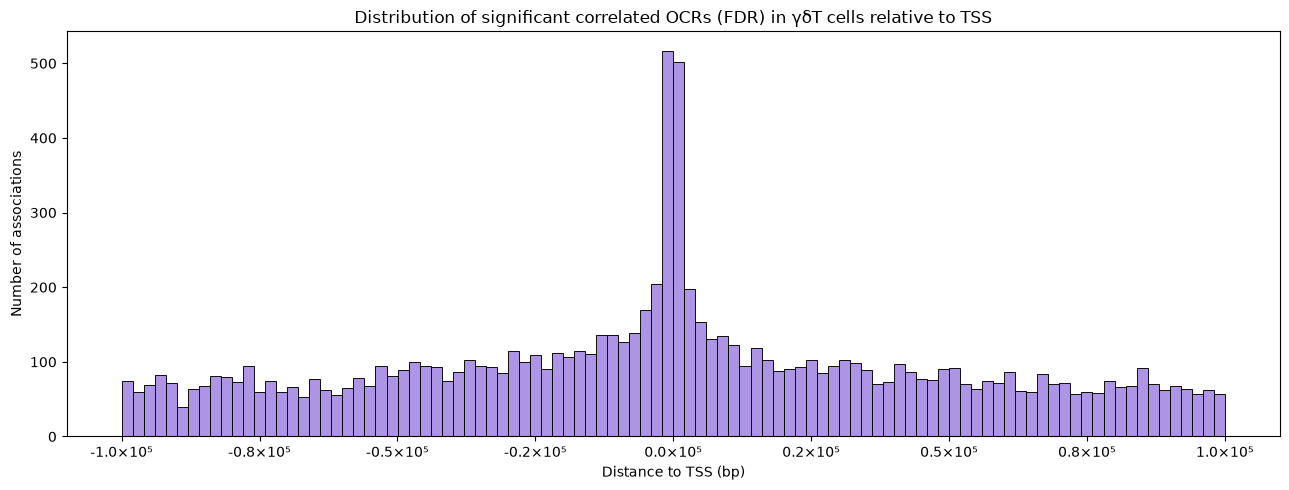

In [29]:
fig, ax = plt.subplots(figsize=(13, 5))

sns.histplot(
    data=corr_fdr_tgd,        #ganzer DataFrame
    x="distance",              #Spaltenname
    bins=100,
    color="mediumpurple",
    ax=ax
)

ax.set_xlabel("Distance to TSS (bp)")
ax.set_ylabel("Number of associations")
ax.set_title("Distribution of significant correlated OCRs (FDR) in γδT cells relative to TSS")

# x-Achse in 100kb-Einheiten wie Yoshida
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e5:.1f}×10⁵")
)
plt.savefig('plots_for_poster/single Barplot DIstance of correlated OCRs to TSS.png', dpi= 300)
plt.tight_layout()
plt.show()

<b> Comparison distance distribution of correlated ORCs between Tgd-cells and all cell types

Text(0.5, 1.02, 'Distance of significant correlated ORCs to TSS')

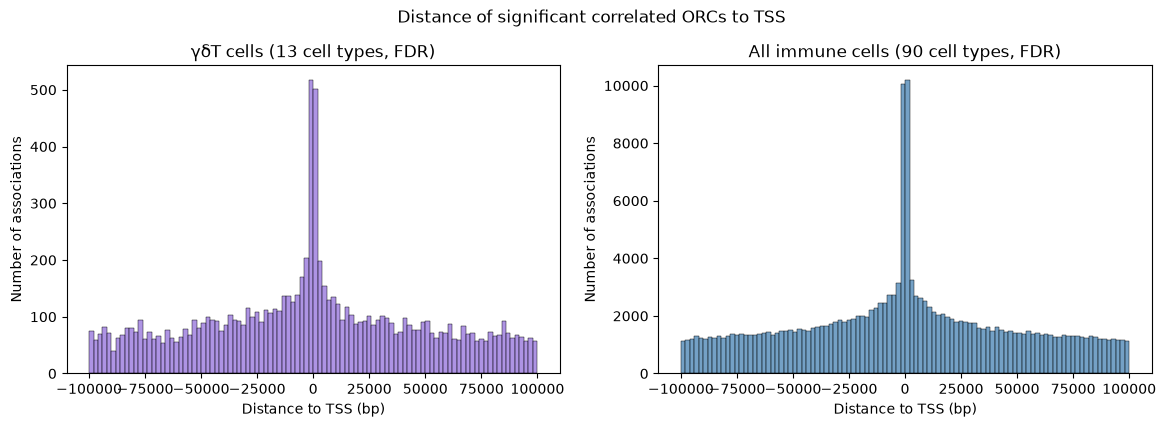

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# γδT
sns.histplot(data=corr_fdr_tgd, x="distance", bins=100, 
             color="mediumpurple", ax=axes[0])
axes[0].set_title("γδT cells (13 cell types, FDR)")
axes[0].set_xlabel("Distance to TSS (bp)")
axes[0].set_ylabel("Number of associations")


# All cells
sns.histplot(data=corr_fdr_all, x="distance", bins=100,
             color="steelblue", ax=axes[1])
axes[1].set_title("All immune cells (90 cell types, FDR)")
axes[1].set_xlabel("Distance to TSS (bp)")
axes[1].set_ylabel("Number of associations")

fig.suptitle(
    "Distance of significant correlated ORCs to TSS",
    fontsize=12, y=1.02
)

For comparison means, the Bonferroni corrected correlation values of Tgd cells were also plotted.

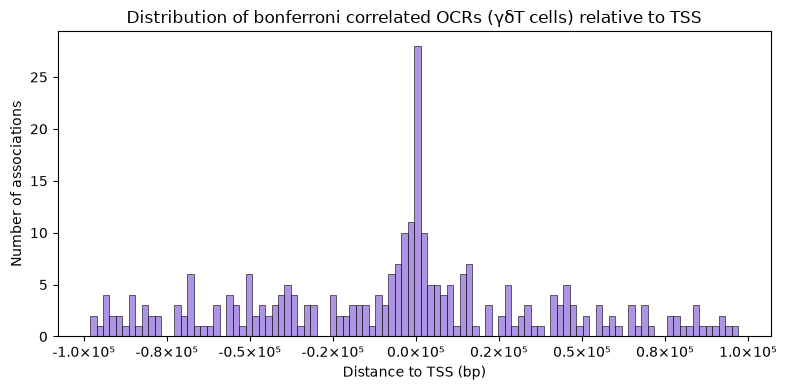

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=corr_bonf_tgd,        # ganzer DataFrame
    x="distance",              # Spaltenname
    bins=100,
    color="mediumpurple",
    ax=ax
)

ax.set_xlabel("Distance to TSS (bp)")
ax.set_ylabel("Number of associations")
ax.set_title("Distribution of bonferroni correlated OCRs (γδT cells) relative to TSS")

# x-Achse in 100kb-Einheiten wie Yoshida
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e5:.1f}×10⁵")
)

plt.tight_layout()
plt.show()

**Results**:

Our plots look slightly different from Yoshida’s plot (3C). This is partly due to the smaller number of cells; here we are only looking at the 13 cells we selected. Furthermore, in the first plot we use FDR correction rather than Bonferroni, which means that more association pairs further away from the TSS survive. The background is flatter here and the decline with increasing distance from the TSS is less steep; however, we have more genes with the FDR method. The Bonferroni plot is more similar to Yoshida’s plot, since Yoahida et al. used Bonferroni for this step. But our Bonferroni distance plot is based on very few correlation pairs that survived the correction and is therefore less stable.

Correlated OCRs are densely clustered near the transcription start site, indicating that chromatin accessibility at
regulatory elements is tightly coupled to gene expression.

## Number of correlated CREs associated with a single gene

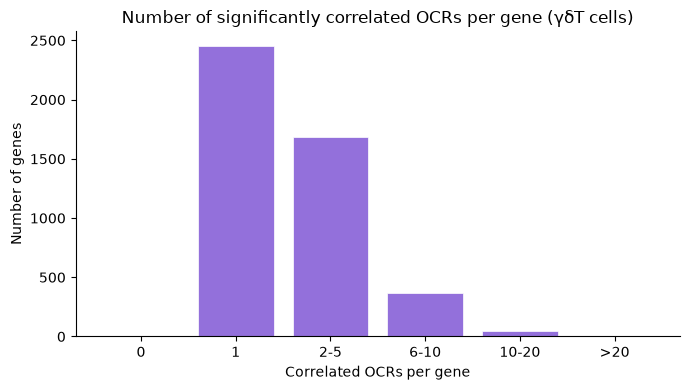

In [32]:
# Anzahl OCRs pro Gen zählen
ocrs_per_gene = corr_fdr_tgd.groupby('gene')['peak_id'].count().reset_index()
ocrs_per_gene.columns = ['gene', 'n_ocrs']

# Kategorien wie Yoshida
bins = [0, 1, 2, 5, 10, 20, np.inf]
labels = ['0', '1', '2-5', '6-10', '10-20', '>20']
ocrs_per_gene['category'] = pd.cut(ocrs_per_gene['n_ocrs'], bins=bins, labels=labels, right=False)

counts = ocrs_per_gene['category'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, counts, color='mediumpurple', edgecolor='white', linewidth=0.5)
ax.set_xlabel("Correlated OCRs per gene")
ax.set_ylabel("Number of genes")
ax.set_title("Number of significantly correlated OCRs per gene (γδT cells)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

As shown in this bar diagram, most OCRs are correlated with only one gene. There are, however, multiple OCRs with 2-5 or even more associated genes. This underlines the complex regulation mechanism on genetic level.

## Peaks with multiple genes:

In [ ]:
peaks_per_gene = corr_fdr_tgd.groupby('peak_id')['gene'].nunique()
peaks_mehrere_Gene = peaks_per_gene[peaks_per_gene > 1]
print(f"\nPeaks assoziiert mit mehreren Genen: {len(peaks_mehrere_Gene)}")
print(f"\nPeaks signifkant assoziiert allgemein : {len(corr_fdr_tgd)}")
print(peaks_mehrere_Gene.sort_values(ascending=False).head(10))


Peaks assoziiert mit mehreren Genen: 900

Peaks signifkant assoziiert allgemein : 9640
peak_id
ImmGenATAC1219.peak_397061    8
ImmGenATAC1219.peak_397075    7
ImmGenATAC1219.peak_397067    7
ImmGenATAC1219.peak_397119    7
ImmGenATAC1219.peak_397057    6
ImmGenATAC1219.peak_246655    6
ImmGenATAC1219.peak_397112    6
ImmGenATAC1219.peak_74475     5
ImmGenATAC1219.peak_415594    5
ImmGenATAC1219.peak_246632    5
Name: gene, dtype: int64


# IL17f correlation analysis

## IL17f: highest correlated ATAC_peak with IL17f across Tgd cells

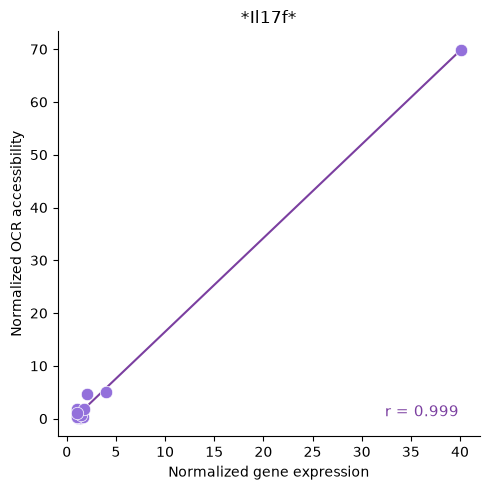

In [ ]:
# Stärkstes Gen aus corr_fdr_tgd (höchstes r)
best = corr_fdr_tgd.loc[corr_fdr_tgd['r'].idxmax()]
gene_name = best['gene']
peak_name_tgd = best['peak_id']

atac_vec = ATAC_Tgd.loc[ATAC_Tgd['ImmGenATAC1219.peakID'] == peak_name_tgd, Tgd_cells].values.flatten()
rna_vec  = RNA_Tgd.loc[gene_name, Tgd_cells].values.flatten()

r_val = best['r']

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rna_vec, atac_vec, color='mediumpurple', edgecolors='white', 
           linewidths=0.5, s=80, zorder=3)


m, b = np.polyfit(rna_vec, atac_vec, 1)
x_line = np.linspace(rna_vec.min(), rna_vec.max(), 100)
ax.plot(x_line, m * x_line + b, color='#7B3FA0', linewidth=1.5)

ax.set_xlabel("Normalized gene expression")
ax.set_ylabel("Normalized OCR accessibility")
ax.set_title(f"*{gene_name}*")
ax.text(0.95, 0.05, f"r = {r_val:.3f}", transform=ax.transAxes,
        ha='right', fontsize=11, color='#7B3FA0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
peak_name_tgd

'ImmGenATAC1219.peak_2086'

In [ ]:
ATAC_pfiltered[ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_tgd]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
1416,ImmGenATAC1219.peak_2086,chr1,20744070,0.0,7.53,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.41,0.1,...,0.44,0.36,0.11,0.53,0.11,0.56,1.26,0.11,1.04,1.26


In [ ]:
# Signal des Peaks über alle Tgd-Zelltypen anzeigen
peak_row = ATAC_pfiltered[ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_tgd]

# Nur die Signal-Spalten (Zelltypen)
peak_signal = peak_row[Tgd_cells].T  # T = transponieren, damit Zelltypen als Zeilen
peak_signal.columns = ['Signal']
peak_signal = peak_signal.sort_values('Signal', ascending=False)

print(peak_signal)

                     Signal
Tgd.g2+d17.LN         69.89
Tgd.g2+d1.LN           5.03
Tgd.Sp                 4.63
Tgd.g2+d17.24a+.Th     1.91
preT.DN2a.Th           1.88
preT.DN1.Th            1.11
Tgd.g1.1+d1.LN         0.99
Tgd.g2+d1.24a+.Th      0.76
Tgd.g1.1+d1.24a+.Th    0.40
T.DN4.Th               0.35
preT.DN3.Th            0.22
preT.DN2b.Th           0.11
MPP4.135+.BM           0.11


Peak aus Tgd-Korrelation (höchstes r, TSS = NaN → Enhancer):  <br>
Dieser Peak ist ein distaler Enhancer, er liegt zwar in der Nähe von Il17f (innerhalb 100kb), aber nicht direkt am Promoter. Das er in der Tgd-spezifischen Korrelation am stärksten ist, bedeutet: seine Zugänglichkeit variiert stark zwischen den γδT-Subtypen und korreliert mit Il17f-Expression. Das ist biologisch sehr interessant; Enhancer sind oft zelltyp- und aktivierungsspezifisch. Dieser Peak könnte ein γδT-spezifischer Enhancer sein, der Il17f nur in bestimmten  γδT-Subtypen (z.B. Tgd.g2+d17) aktiviert. Dieser peak ist für uns besonders interessant, da Tgd.g2+d17.LN eine Zellart ist, die Psoriasis eine entscheidende Rolle spielt und für ihre IL17f Produktion bekannt ist.<p>

## IL17f: highest correlated ATAC_peak with IL17f across all cells

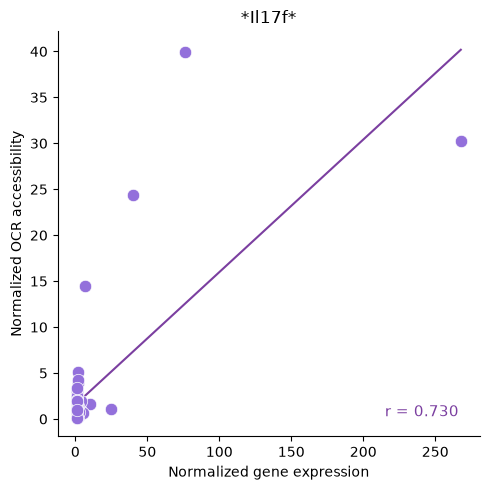

In [ ]:
gene_of_interest = 'Il17f'

subset = corr_fdr_all[corr_fdr_all['gene'] == gene_of_interest]
best_all = subset.loc[subset['r'].idxmax()]
peak_name_all = best_all['peak_id']
r_val = best_all['r']

atac_vec = ATAC_pfiltered.loc[
    ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_all, signal_cols_all
].values.flatten()

rna_vec = RNA_seq.loc[gene_of_interest, signal_cols_all].values.flatten()

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rna_vec, atac_vec, color='mediumpurple', edgecolors='white',
           linewidths=0.5, s=80, zorder=3)

m, b = np.polyfit(rna_vec, atac_vec, 1)
x_line = np.linspace(rna_vec.min(), rna_vec.max(), 100)
ax.plot(x_line, m * x_line + b, color='#7B3FA0', linewidth=1.5)

ax.set_xlabel("Normalized gene expression")
ax.set_ylabel("Normalized OCR accessibility")
ax.set_title(f"*{gene_of_interest}*")
ax.text(0.95, 0.05, f"r = {r_val:.3f}", transform=ax.transAxes,
        ha='right', fontsize=11, color='#7B3FA0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

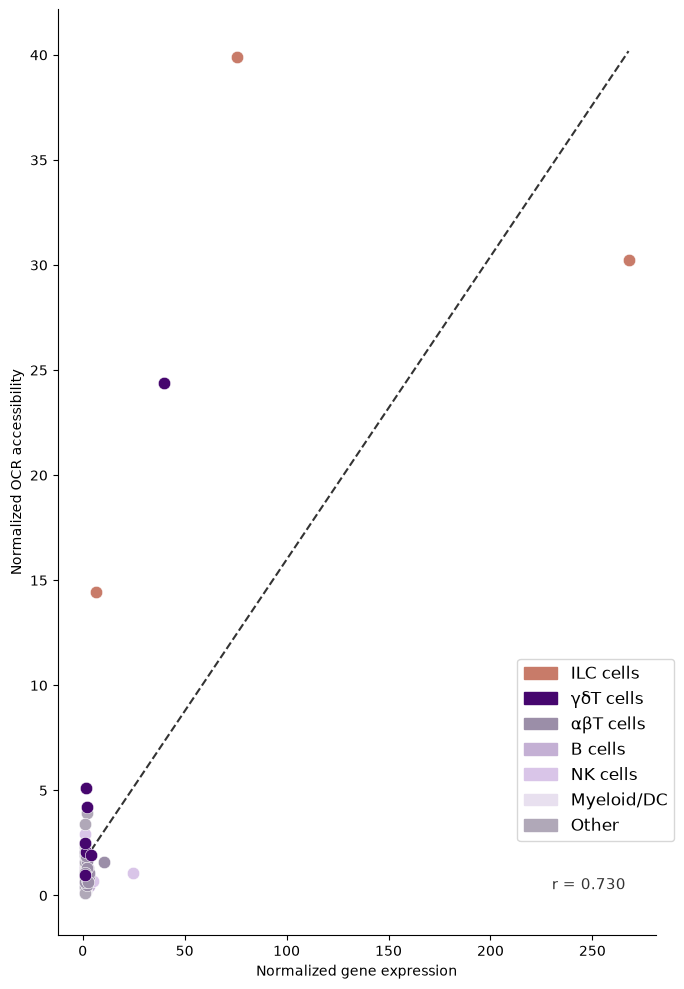

In [ ]:
# Zelltyp-Kategorien definieren
import matplotlib.patches as mpatches
def get_cell_category(col):
    if 'Tgd' in col:
        return 'γδT cells'
    elif 'ILC' in col:
        return 'ILC cells'
    elif col.startswith('T.') or col.startswith('T8') or col.startswith('Treg') or 'preT' in col:
        return 'αβT cells'
    elif col.startswith('B.') or col.startswith('proB') or col.startswith('preB'):
        return 'B cells'
    elif col.startswith('NK'):
        return 'NK cells'
    elif col.startswith('MF') or col.startswith('Mo') or col.startswith('DC') or col.startswith('GN'):
        return 'Myeloid/DC'
    else:
        return 'Other'

# Farben pro Kategorie
color_map = {
    'ILC cells':   "#C87B69",
    'γδT cells':   "#46066E",  
    'αβT cells':   "#9B8EA8",  
    'B cells':     "#C4B0D4",  
    'NK cells':    "#D9C5E8",  
    'Myeloid/DC':  "#E8E0EF",  
    'Other':       "#B0A8B8"   
}

handles = [
    mpatches.Patch(color=color, label=label) 
    for label, color in color_map.items()  # Reihenfolge aus dem Dict
]


# DataFrame für Plot erstellen
plot_df = pd.DataFrame({
    'rna':      rna_vec,
    'atac':     atac_vec,
    'celltype': [get_cell_category(c) for c in signal_cols_all]
})

# Plot
fig, ax = plt.subplots(figsize=(7, 10))

for cat, group in plot_df.groupby('celltype'):
    ax.scatter(group['rna'], group['atac'],
               color=color_map[cat], label=cat,
               edgecolors='white', linewidths=0.4,
               s=80, zorder=3)

# Regressionslinie
m, b = np.polyfit(rna_vec, atac_vec, 1)
x_line = np.linspace(rna_vec.min(), rna_vec.max(), 100)
ax.plot(x_line, m * x_line + b, color='#333333', linewidth=1.5, linestyle='--')

ax.set_xlabel("Normalized gene expression")
ax.set_ylabel("Normalized OCR accessibility")
#ax.set_title("Il17f — OCR accessibility vs. gene expression")
ax.text(0.95, 0.05, f"r = {r_val:.3f}", transform=ax.transAxes,
        ha='right', fontsize=11, color='#333333')
ax.legend(handles=handles, loc='center', bbox_to_anchor=(0.9, 0.2), 
          frameon=True, fontsize=12,
          framealpha=0.9, edgecolor='lightgrey')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('plots_for_poster/scatterplot IL17f- OCR accessibility vs gene expression.png', dpi= 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

Il17f, a cytokine characteristically produced by γδT cells, shows a robust correlation (r = 0.730) between OCR accessibility and gene expression across all 90 immune cell types. The majority of cell types, including B cells, NK cells, and myeloid populations, show both low Il17f expression and low chromatin accessibility at this locus. In contrast, γδT cells and ILC3s, known producers of Il17 family cytokines, cluster at higher expression and accessibility values. This demonstrates that CRE activity at the Il17f locus is tightly linked to lineage-specific gene expression, consistent with the principle that correlation of chromatin accessibility with gene expression across diverse cell types can identify functionally relevant cis-regulatory elements.

In [ ]:
peak_name_all

'ImmGenATAC1219.peak_2095'

In [ ]:
ATAC_pfiltered[ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_all]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
1422,ImmGenATAC1219.peak_2095,chr1,20784347,0.55,11.49,1.0,Il17f,"Il17a,Il17f,Mcm3",0.41,0.71,...,2.1,1.81,1.14,0.11,1.82,1.94,0.1,1.92,3.39,0.94


In [ ]:
# Signal des Peaks über alle Tgd-Zelltypen anzeigen
peak_row = ATAC_pfiltered[ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_all]

# Nur die Signal-Spalten (Zelltypen)
peak_signal = peak_row[Tgd_cells].T  # T = transponieren, damit Zelltypen als Zeilen
peak_signal.columns = ['Signal']
peak_signal = peak_signal.sort_values('Signal', ascending=False)

print(peak_signal)

                     Signal
Tgd.g2+d17.LN         24.37
Tgd.g2+d17.24a+.Th     5.12
Tgd.Sp                 4.21
Tgd.g1.1+d1.24a+.Th    2.51
preT.DN1.Th            2.09
Tgd.g2+d1.24a+.Th      2.07
Tgd.g2+d1.LN           1.95
preT.DN2b.Th           1.78
MPP4.135+.BM           1.58
preT.DN2a.Th           1.17
preT.DN3.Th            1.01
Tgd.g1.1+d1.LN         0.99
T.DN4.Th               0.78


Peak aus All-Cells-Korrelation (höchstes r, TSS = Il17f → Promoter): <br>
Dieser Peak ist der Promoter von Il17f selbst. Er korreliert gut über alle 90 Zelltypen, weil der Promoter in allen Il17f-exprimierenden Zellen (γδT + ILC3) zugänglich sein muss, das ist eine "konstitutivere" Regulation. Promoter-Zugänglichkeit ist oft weniger zelltyp-spezifisch als Enhancer-Zugänglichkeit.

**Comparison enhancer peak 2086 and promoter peak 2095.**

Both the distal enhancer and promoter-proximal OCRs at the Il17f locus show highest chromatin accessibility in Tgd.g2+d17 cells- the IL-17-producing γδT subtype implicated in psoriatic inflammation (Veras et al., 2022). Notably, the distal enhancer OCR shows higher accessibility (signal 69.89) than the promoter (24.37) in Tgd.g2+d17.LN cells, consistent with the established role of lineage-specific enhancers as primary drivers of cell-type-restricted gene expression (Yoshida et al., 2019; Corces et al., 2018). This pattern demonstrates that CRE activity at the Il17f locus is tightly restricted to IL-17-competent γδT cells, and supports a model in which enhancer-driven chromatin remodeling precedes and facilitates promoter activation — as previously described for immune cell differentiation (Buenrostro et al., 2013; Calderon et al., 2019).

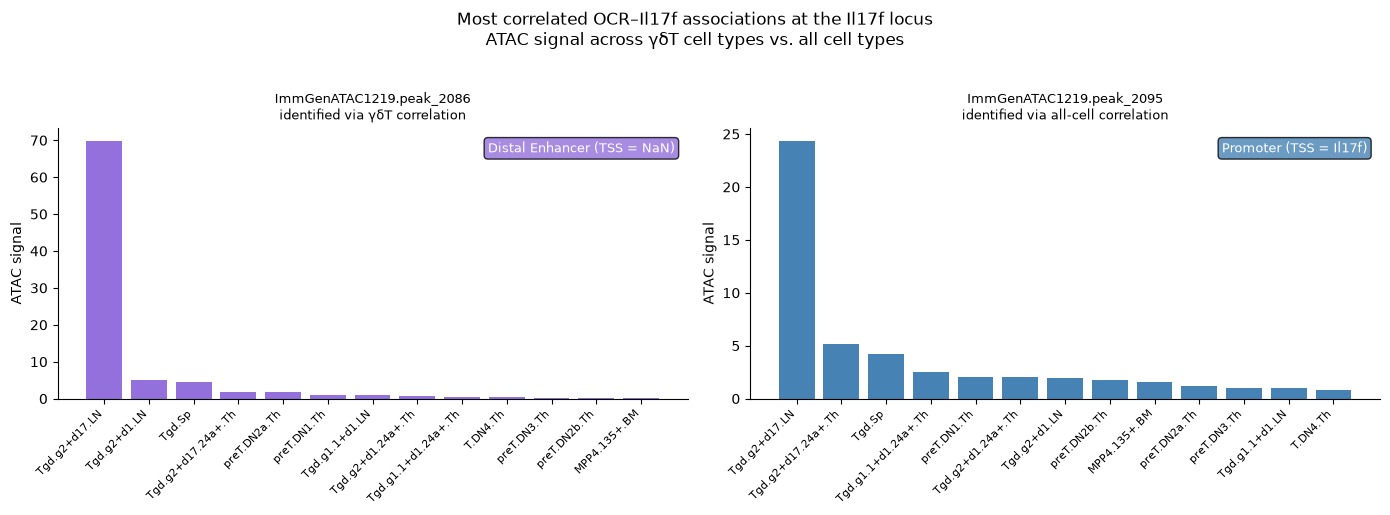

In [ ]:
peak_2086 = "ImmGenATAC1219.peak_2086"  # Enhancer-Peak (identified via γδT correlation)
peak_2095 = "ImmGenATAC1219.peak_2095"  # Promoter-Peak (identified via all-cell correlation)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, peak, color, label in zip(
    axes,
    [peak_2086, peak_2095],
    ['mediumpurple', 'steelblue'],
    ['Distal Enhancer (TSS = NaN)\nidentified via γδT correlation',
     'Promoter (TSS = Il17f)\nidentified via all-cell correlation']
):
    row = ATAC_Tgd[ATAC_Tgd['ImmGenATAC1219.peakID'] == peak]
    signal = row[Tgd_cells].T
    signal.columns = ['Signal']
    signal = signal.sort_values('Signal', ascending=False)

    ax.bar(range(len(signal)), signal['Signal'], color=color)
    ax.set_xticks(range(len(signal)))
    ax.set_xticklabels(signal.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel("ATAC signal")
    ax.set_title(
    f"{peak}\nidentified via {'γδT' if peak == peak_2086 else 'all-cell'} correlation",
    fontsize=9
)
    ax.annotate(label.split('\n')[0],
                xy=(0.98, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=9, color='white',
                bbox=dict(boxstyle='round', fc=color, alpha=0.8))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    "Most correlated OCR–Il17f associations at the Il17f locus\n"
    "ATAC signal across γδT cell types vs. all cell types",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

**Enhancer vs. Promoter: IL17f**

Genome-wide, promoter OCRs show higher mean accessibility than enhancer OCRs across all 90 immune cell types, consistent with their role as constitutively open regulatory elements. In contrast, enhancer OCRs exhibit greater signal variability (higher CV), reflecting their cell-type-specific activation patterns (03_Enhancer vs Promoter analysis). <br> This pattern is exemplified at the Il17f locus: while the promoter shows moderate accessibility across cell types, the distal enhancer OCR displays extremely high accessibility specifically in Tgd.g2+d17 cells (signal 69.89 vs. ~0.1–2 in other cell types), demonstrating the hallmark behavior of a lineage-specific enhancer driving Il17f expression selectively in IL-17-producing γδT cells implicated in psoriatic inflammation (Veras et al., 2022).

## Are Promoters usually associated with their own genes?

In [34]:
ATAC_promoters = ATAC_pfiltered[-ATAC_pfiltered["TSS"].isnull()]
ATAC_promoters

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
14,ImmGenATAC1219.peak_21,chr1,3671437,0.72,2.02,1.0,Xkr4,Xkr4,0.41,3.68,...,2.53,0.10,0.11,1.87,0.92,4.97,2.62,2.64,2.83,17.14
99,ImmGenATAC1219.peak_140,chr1,4785675,0.41,15.87,1.0,Mrpl15,"Mrpl15,Lypla1,Tcea1",9.93,20.06,...,21.99,24.19,21.76,22.06,20.80,33.25,23.63,20.90,13.30,22.38
103,ImmGenATAC1219.peak_146,chr1,4807877,0.47,25.12,1.0,Lypla1,"Mrpl15,Lypla1,Tcea1",29.54,42.40,...,26.85,17.69,41.52,42.24,42.23,32.82,31.65,38.34,26.68,33.27
108,ImmGenATAC1219.peak_158,chr1,4857752,0.12,45.65,1.0,Tcea1,"Mrpl15,Lypla1,Tcea1",115.42,141.25,...,80.17,108.52,85.43,79.55,92.80,133.71,85.20,101.38,137.79,129.55
110,ImmGenATAC1219.peak_160,chr1,4858351,0.02,7.78,1.0,Tcea1,"Mrpl15,Lypla1,Tcea1",4.37,6.07,...,10.55,11.20,10.07,10.37,9.80,8.34,8.76,17.31,8.39,11.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362251,ImmGenATAC1219.peak_512468,chrX_GL456233_random,39222,0.32,73.75,1.0,Vamp7,"Vamp7,Spry3",57.63,42.40,...,37.95,58.81,61.00,38.21,37.03,63.17,48.63,61.16,82.32,48.00
362257,ImmGenATAC1219.peak_512478,chrX_GL456233_random,159627,0.12,16.28,1.0,Tmlhe,"Spry3,Tmlhe",22.66,21.83,...,3.12,2.21,9.63,0.47,1.75,16.68,8.32,13.71,29.25,5.34
362277,ImmGenATAC1219.peak_512507,chrY,1010556,0.18,13.45,1.0,Eif2s3y,"Eif2s3y,Tspy-ps",12.99,11.79,...,21.53,20.30,17.67,20.86,16.23,9.28,24.00,12.94,11.58,18.65
362287,ImmGenATAC1219.peak_512523,chrY,1245808,0.18,18.59,1.0,Uty,"Uty,Ddx3y",19.40,25.33,...,34.26,34.61,21.57,23.95,24.12,30.97,36.01,30.23,38.30,35.58


In [35]:
promoter_peaks = ATAC_promoters[['ImmGenATAC1219.peakID', 'TSS']]

#welche Promoter-Peaks haben signifikante Assoziationen
promoter_corr_fdr = corr_fdr_tgd.merge(
    promoter_peaks, 
    left_on='peak_id', 
    right_on='ImmGenATAC1219.peakID'
)

# assoziierte Gen dasselbe wie Gen in der TSS-Spalte
promoter_corr_fdr['own_gene'] = promoter_corr_fdr['gene'] == promoter_corr_fdr['TSS']

#jeder peak zählt nur einmal
print(f"Promoter assoziert mit eigenem Gen: {promoter_corr_fdr[promoter_corr_fdr['own_gene']]['peak_id'].nunique()}")
print(f"Promoter assoziert mit anderem Gen: {promoter_corr_fdr[~promoter_corr_fdr['own_gene']]['peak_id'].nunique()}")
print(f"Promoter mit signifikanten Assoziationen insgesamt: {promoter_corr_fdr['peak_id'].nunique()}")


Promoter assoziert mit eigenem Gen: 313
Promoter assoziert mit anderem Gen: 273
Promoter mit signifikanten Assoziationen insgesamt: 525


Of 525 promoter peaks with a significant association, 313 (60%) were linked to their own gene, while 273 (52%) were also linked to another gene (51 overlapping both). This suggests that a substantial fraction of promoters are not exclusively associated with their own gene, in contrast to the ~90% "nearest gene" accuracy reported by Yoshida et al.

## Peaks with multiple genes:

In [ ]:
peaks_per_gene = corr_fdr_tgd.groupby('peak_id')['gene'].nunique()
peaks_mehrere_Gene = peaks_per_gene[peaks_per_gene > 1]
print(f"\nPeaks assoziiert mit mehreren Genen: {len(peaks_mehrere_Gene)}")
print(f"\nPeaks signifkant assoziiert allgemein : {len(corr_fdr_tgd)}")
print(peaks_mehrere_Gene.sort_values(ascending=False).head(10))


Peaks assoziiert mit mehreren Genen: 900

Peaks signifkant assoziiert allgemein : 9640
peak_id
ImmGenATAC1219.peak_397061    8
ImmGenATAC1219.peak_397075    7
ImmGenATAC1219.peak_397067    7
ImmGenATAC1219.peak_397119    7
ImmGenATAC1219.peak_397057    6
ImmGenATAC1219.peak_246655    6
ImmGenATAC1219.peak_397112    6
ImmGenATAC1219.peak_74475     5
ImmGenATAC1219.peak_415594    5
ImmGenATAC1219.peak_246632    5
Name: gene, dtype: int64


Across all 9,640 significant peak-gene associations, 900 peaks (~9%) were linked to more than one gene, with the most connected peaks (up to 8 genes) clustering in the same genomic region. This points to considerable redundancy in cis-regulatory associations, consistent with prior reports that most genes are linked to multiple, often interconnected, regulatory elements.